In [179]:
import numpy as np
import pandas as pd

In [180]:
df = pd.read_csv("spam.csv",encoding_errors='ignore')

In [181]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2788,ham,got wat to buy tell us then _ no need to come...,NaN,NaN,NaN
2187,ham,Oh god. I'm gonna Google nearby cliffs now.,NaN,NaN,NaN
919,ham,Dont talk to him ever ok its my word.,NaN,NaN,NaN
5387,ham,I will be gentle baby! Soon you will be taking...,NaN,NaN,NaN
3279,ham,Badrith is only for chennai:)i will surely pic...,NaN,NaN,NaN


In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [183]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace = True)

In [184]:
df.sample(5)

,v1,v2
1544,ham,After completed degree. There is no use in joi...
3322,ham,"She said,'' do u mind if I go into the bedroom..."
2002,spam,TheMob>Yo yo yo-Here comes a new selection of ...
3684,ham,Wake me up at &lt;#&gt; am morning:)
290,ham,Hey you told your name to gautham ah?


In [185]:
df.rename(columns ={'v1' :'Target','v2' :'Text'},inplace = True)

In [186]:
df.sample(5)

,Target,Text
2686,ham,There r many model..sony ericson also der.. &l...
2105,ham,I fetch yun or u fetch?
2880,ham,Printer is cool. I mean groovy. Wine is groovying
3222,ham,Well that must be a pain to catch
2241,ham,U buy newspapers already?


In [187]:
df.head()

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [188]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [189]:
df['Target'] = encoder.fit_transform(df['Target'])

In [190]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [191]:
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [192]:
df.duplicated().sum()

404

In [193]:
df = df.drop_duplicates(keep ="first")

In [194]:
df.duplicated().sum()

0

# EDA

In [196]:
df['Target'].value_counts()

Target
0    4516
1     652
Name: count, dtype: int64

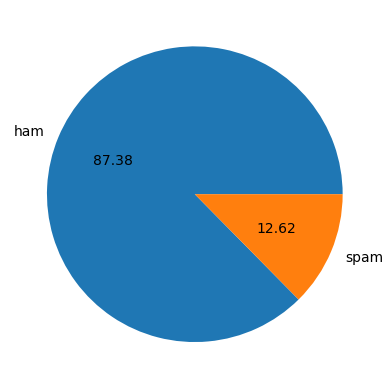

In [197]:
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [198]:
import nltk


In [199]:
!pip install nltk

In [200]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\RAJAT\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [201]:
df['Num character'] = df['Text'].apply(len)

In [202]:
df.head()

,Target,Text,Num character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [203]:
df['num_words'] = df['Text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [204]:
df.head()

,Target,Text,Num character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [205]:
df['Num Sentance'] = df['Text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [206]:
df.head()

,Target,Text,Num character,num_words,Num Sentance
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [207]:
df[['Num character','num_words','Num Sentance']].describe()

,Num character,num_words,Num Sentance
count,5168.000000,5168.000000,5168.000000
mean,78.759481,18.441176,1.966331
std,58.104099,13.327587,1.449367
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,116.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [208]:
import seaborn as sns

<Axes: xlabel='Num character', ylabel='Count'>

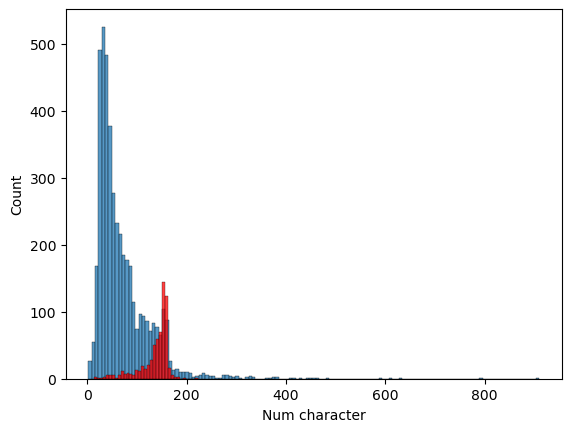

In [209]:

sns.histplot(df[df['Target'] == 0]['Num character'])
sns.histplot(df[df['Target'] == 1]['Num character'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

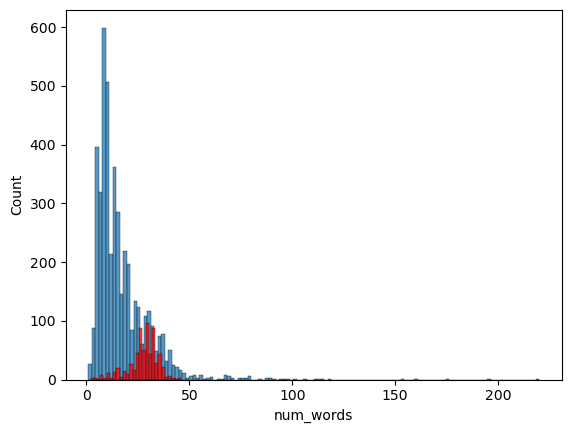

In [210]:
sns.histplot(df[df['Target'] == 0]['num_words'])
sns.histplot(df[df['Target'] == 1]['num_words'],color='red')

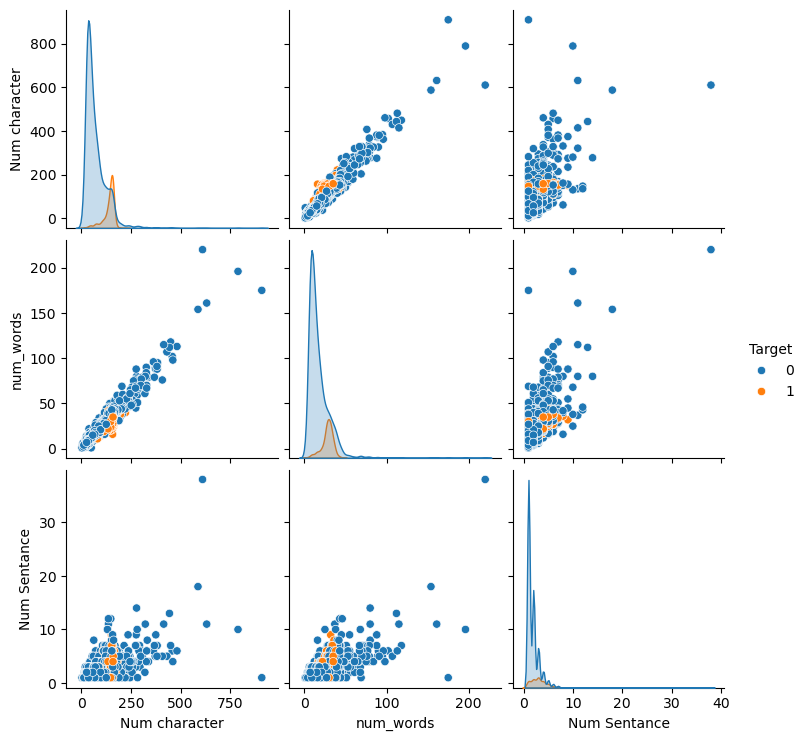

In [211]:
sns.pairplot(df,hue='Target')

In [212]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    
    # Now 'stopwords' and 'string' will be recognized
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        ps = PorterStemmer()
        y.append(ps.stem(i))
            
    return " ".join(y)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\RAJAT\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RAJAT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [213]:
transform_text('Hi how much % u got on 10 class')
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [214]:
df['transformed_text'] = df['Text'].apply(transform_text)

In [215]:
df.head()

,Target,Text,Num character,num_words,Num Sentance,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [216]:
!pip install wordcloud

In [217]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [218]:
spam_wc = wc.generate(df[df['Target'] == 1]['transformed_text'].str.cat(sep=" "))

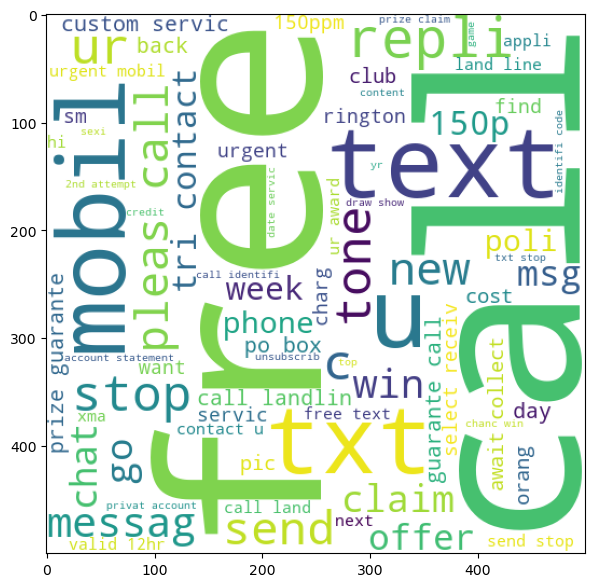

In [219]:
plt.figure(figsize =(20,7))
plt.imshow(spam_wc)

In [220]:
ham_wc = wc.generate(df[df['Target']==0]['transformed_text'].str.cat(sep=" "))

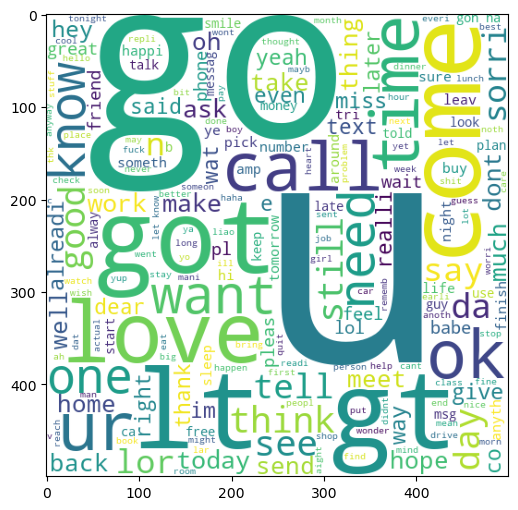

In [221]:
plt.figure(figsize= (20,6))
plt.imshow(ham_wc)

In [222]:
spam_list = []
for msg in df[df['Target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_list.append(word)
    

In [223]:
spam_list

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 '900',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '

In [224]:
from collections import Counter
import pandas as pd
pd.DataFrame(Counter(spam_list).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,102


<Axes: ylabel='0'>

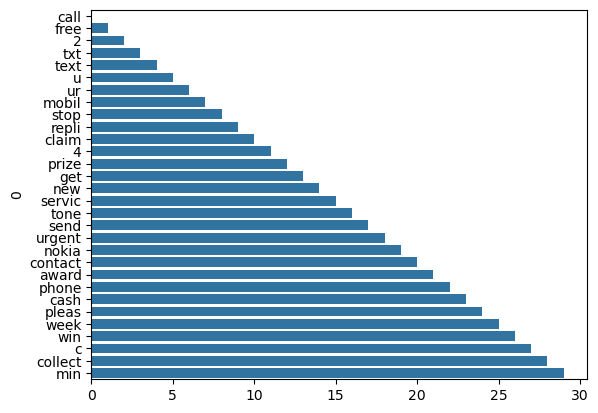

In [225]:
sns.barplot(pd.DataFrame(Counter(spam_list).most_common(30))[0])

<Axes: ylabel='1'>

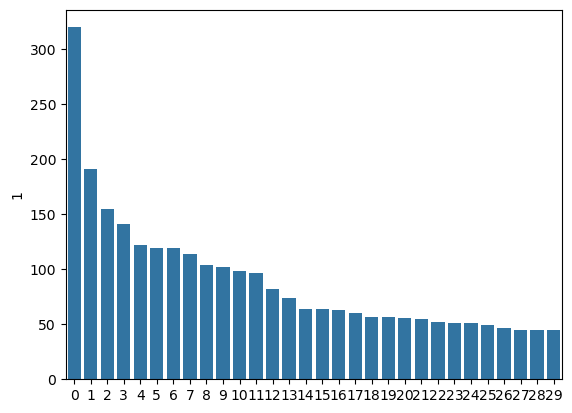

In [226]:
sns.barplot(pd.DataFrame(Counter(spam_list).most_common(30))[1])


In [227]:
ham_list = []
for msg in df[df['Target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_list.append(word)

In [228]:
ham_list

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 '9',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 '2',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'that',
 'way'

In [229]:
pd.DataFrame(Counter(ham_list).most_common(30))

,0,1
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


<Axes: ylabel='0'>

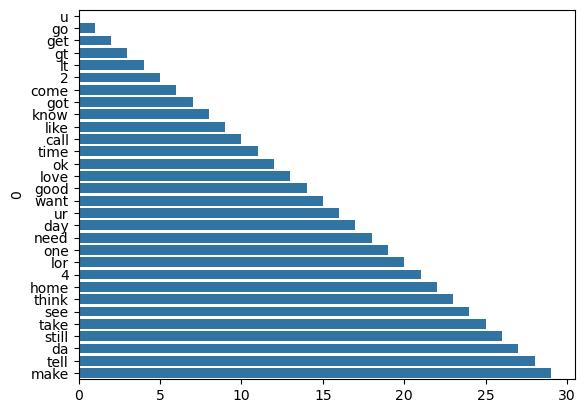

In [230]:
sns.barplot(pd.DataFrame(Counter(ham_list).most_common(30))[0])

<Axes: ylabel='1'>

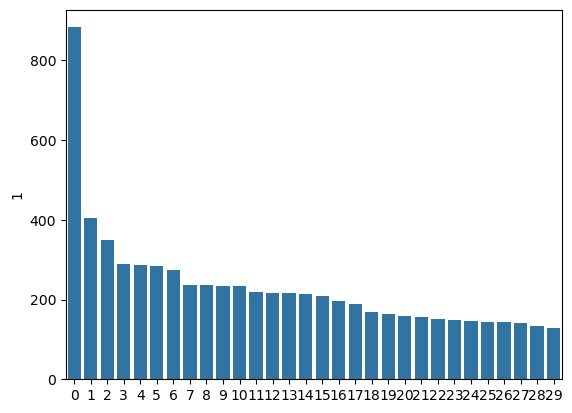

In [231]:
sns.barplot(pd.DataFrame(Counter(ham_list).most_common(30))[1])

In [232]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [233]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [234]:
X.shape

(5168, 3000)

In [235]:
y = df['Target'].values

In [236]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [237]:
from sklearn.model_selection import train_test_split

In [238]:
X_test,X_train,y_test,y_train = train_test_split(X,y,test_size = 0.2,random_state = 2)

In [239]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [240]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [241]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print("accuracy_score",accuracy_score(y_test,y_pred1))
print("confusion_matrix",confusion_matrix(y_test,y_pred1))
print("precision_score",precision_score(y_test,y_pred1))

accuracy_score 0.8814707305273343
confusion_matrix [[3250  373]
 [ 117  394]]
precision_score 0.5136897001303781


In [242]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9315432994678278
[[3623    0]
 [ 283  228]]
1.0


In [243]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print("accuracy_score",accuracy_score(y_test,y_pred3))
print("confusion_matrix",confusion_matrix(y_test,y_pred3))
print("precision_score",precision_score(y_test,y_pred3))

accuracy_score 0.9484760522496372
confusion_matrix [[3618    5]
 [ 208  303]]
precision_score 0.9837662337662337


In [244]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [245]:
!pip install xgboost

In [246]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [247]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [317]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [319]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9629898403483309, 0.9475)

In [321]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9629898403483309
Precision -  0.9475
For  KN
Accuracy -  0.8824383164005806
Precision -  1.0
For  NB
Accuracy -  0.9315432994678278
Precision -  1.0
For  DT
Accuracy -  0.9346879535558781
Precision -  0.814621409921671
For  LR
Accuracy -  0.919206579583938
Precision -  0.8127208480565371
For  RF
Accuracy -  0.9586357039187228
Precision -  0.9941860465116279


D:\backup\laptop backup\download backup\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For  AdaBoost
Accuracy -  0.9443638122883405
Precision -  0.781563126252505
For  BgC
Accuracy -  0.9407353652636672
Precision -  0.7577519379844961
For  ETC
Accuracy -  0.9629898403483309
Precision -  0.976063829787234
For  GBDT
Accuracy -  0.9465408805031447
Precision -  0.8835978835978836
For  xgb
Accuracy -  0.947992259313014
Precision -  0.8457943925233645


In [322]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [325]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.882438,1.000000
2,NB,0.931543,1.000000
5,RF,0.958636,0.994186
8,ETC,0.962990,0.976064
0,SVC,0.962990,0.947500
9,GBDT,0.946541,0.883598
10,xgb,0.947992,0.845794
3,DT,0.934688,0.814621
4,LR,0.919207,0.812721
6,AdaBoost,0.944364,0.781563


In [331]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [335]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.882438
1,NB,Accuracy,0.931543
2,RF,Accuracy,0.958636
3,ETC,Accuracy,0.962990
4,SVC,Accuracy,0.962990
5,GBDT,Accuracy,0.946541
6,xgb,Accuracy,0.947992
7,DT,Accuracy,0.934688
8,LR,Accuracy,0.919207
9,AdaBoost,Accuracy,0.944364


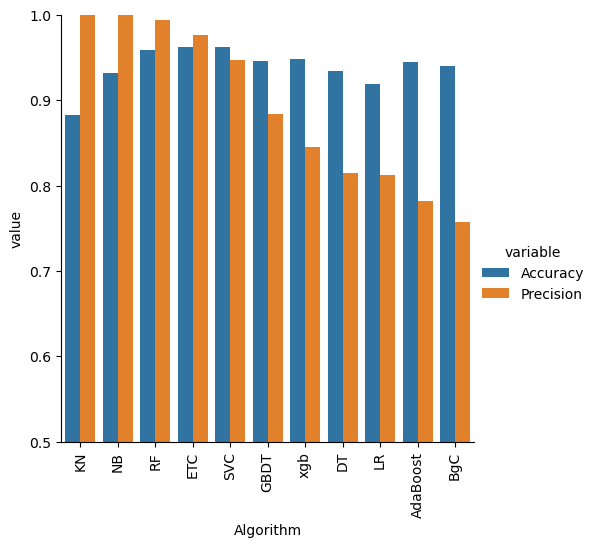

In [333]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [337]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))